PROJECT 1: PREDICTION OF AGRICULTURE CROP PRODUCTION & YIELD IN INDIA
Author: Shrey Kandpal | Domain: Data Science & Machine Learning


IMPORTING ESSENTIAL LIBRARIES

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ANALYSING INDIA'S FOODGRAIN TRENDS (USING produce.csv)

  20-YEAR NATIONAL PRODUCTION ANALYSIS   
India 20-Year Foodgrain Production (Sample):
    Year  Foodgrain_Production_Million_Tonnes
17  2010                           218.107372
18  2011                           244.491809
19  2012                           259.286253
20  2013                           257.130000
21  2014                           264.380600


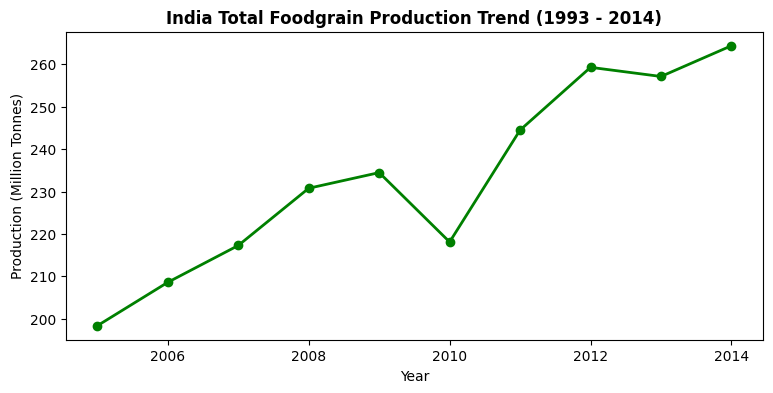

In [29]:
print("  20-YEAR NATIONAL PRODUCTION ANALYSIS   ")
print("=================================================")
# 1. Load produce.csv
produce_df = pd.read_csv("produce.csv")
produce_df.columns = produce_df.columns.str.strip()

# 2. Extract total agricultural foodgrain production row (1993 - 2014)
# Changed from .str.contains to exact match to ensure a single row for total production
foodgrain_row = produce_df[produce_df['Particulars'] == 'Agricultural Production Foodgrains']

# Extract year columns (columns starting with '3-')
year_cols = [col for col in foodgrain_row.columns if col.startswith('3-')]
years = [int(col.split('-')[1]) for col in year_cols]
production_values = foodgrain_row[year_cols].values.flatten().astype(float)

# Create a clean time-series dataframe
trend_df = pd.DataFrame({
    'Year': years,
    'Foodgrain_Production_Million_Tonnes': production_values
})

print("India 20-Year Foodgrain Production (Sample):")

print(trend_df.tail(5))

# 3. Plot the 20-Year National Production Trend
plt.figure(figsize=(9, 4))
plt.plot(trend_df['Year'], trend_df['Foodgrain_Production_Million_Tonnes'], marker='o', color='green', linewidth=2)
plt.title("India Total Foodgrain Production Trend (1993 - 2014)", fontsize=12, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Production (Million Tonnes)")
plt.savefig("india_foodgrain_trend.png", dpi=300)
plt.show()

STATE BASED MACHINE LEARNING MODEL (USING datafile (1).csv)

In [31]:

print("   CROP YIELD PREDICTION MODEL             ")
print("=================================================")
# 1. Load datafile (1).csv
df = pd.read_csv("datafile (1).csv")

# 2. Rename columns to clean, simple variable names
df.columns = [
    'Crop',
    'State',
    'Cost_Cultivation_A2_FL',
    'Cost_Cultivation_C2',
    'Cost_Production_C2',
    'Yield'
]

# 3. Clean string values
df['Crop'] = df['Crop'].str.strip().str.title()
df['State'] = df['State'].str.strip().str.title()

print(f"Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 3 Records:")
print(df.head(3))

   CROP YIELD PREDICTION MODEL             
Dataset Size: 49 rows, 6 columns

First 3 Records:
    Crop          State  Cost_Cultivation_A2_FL  Cost_Cultivation_C2  \
0  Arhar  Uttar Pradesh                 9794.05             23076.74   
1  Arhar      Karnataka                10593.15             16528.68   
2  Arhar        Gujarat                13468.82             19551.90   

   Cost_Production_C2  Yield  
0             1941.55   9.83  
1             2172.46   7.47  
2             1898.30   9.59  


EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION

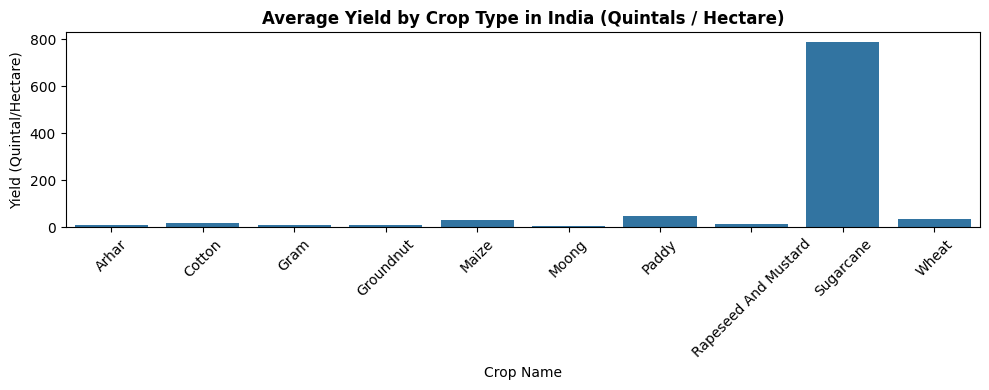

In [32]:
# Plot 1: Average Yield by Crop Type
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x='Crop', y='Yield', estimator=np.mean, errorbar=None)
plt.title('Average Yield by Crop Type in India (Quintals / Hectare)', fontsize=12, fontweight='bold')
plt.xlabel('Crop Name')
plt.ylabel('Yield (Quintal/Hectare)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("yield_by_crop.png", dpi=300)
plt.show()

ASSIGNING FEATURES (X) AND DEPENDENT VARIABLE (y)

In [33]:
# X = Input variables (Crop, State, and Costs)
# y = Output variable (Yield)
X = df[['Crop', 'State', 'Cost_Cultivation_A2_FL', 'Cost_Cultivation_C2', 'Cost_Production_C2']]
y = df['Yield']

# One-Hot Encoding: Converts text columns (Crop, State) into binary numerical columns (0, 1)
X_encoded = pd.get_dummies(X, columns=['Crop', 'State'], drop_first=True)

# Split into 80% Training set and 20% Testing set
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)


print("             TRAIN / TEST SPLIT                   ")
print("=================================================")
print(f"Training Samples: {X_train.shape[0]} ({X_train.shape[1]} features)")
print(f"Testing Samples:  {X_test.shape[0]}")

             TRAIN / TEST SPLIT                   
Training Samples: 39 (24 features)
Testing Samples:  10


MODEL TRAINING & EVALUATION

In [34]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Metrics Calculation
print("             MODEL PERFORMANCE METRICS            ")
print("=================================================")
print("1. LINEAR REGRESSION (BASELINE):")
print(f"   • R² Score: {r2_score(y_test, lr_preds):.2f}")
print(f"   • RMSE:     {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f} Quintals/Ha")
print(f"   • MAE:      {mean_absolute_error(y_test, lr_preds):.2f} Quintals/Ha")

print("\n2. RANDOM FOREST REGRESSOR (FINAL MODEL):")
print(f"   • R² Score: {r2_score(y_test, rf_preds):.2f}")
print(f"   • RMSE:     {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f} Quintals/Ha")
print(f"   • MAE:      {mean_absolute_error(y_test, rf_preds):.2f} Quintals/Ha")

             MODEL PERFORMANCE METRICS            
1. LINEAR REGRESSION (BASELINE):
   • R² Score: 0.91
   • RMSE:     91.86 Quintals/Ha
   • MAE:      66.93 Quintals/Ha

2. RANDOM FOREST REGRESSOR (FINAL MODEL):
   • R² Score: 0.96
   • RMSE:     62.55 Quintals/Ha
   • MAE:      23.74 Quintals/Ha


COMPARE TABLES (ACTUAL VS PREDICTED)

In [35]:
comparison_table = pd.DataFrame({
    'Actual Yield (Quintal/Ha)': y_test.values,
    'Predicted Yield (Linear Reg)': np.round(lr_preds, 2),
    'Predicted Yield (Random Forest)': np.round(rf_preds, 2)
})
print("     SAMPLE TEST PREDICTIONS VS ACTUAL YIELD      ")
print("=================================================")
print(comparison_table.head(10))

     SAMPLE TEST PREDICTIONS VS ACTUAL YIELD      
   Actual Yield (Quintal/Ha)  Predicted Yield (Linear Reg)  \
0                       8.05                        -15.14   
1                      23.59                          2.04   
2                      34.99                         49.27   
3                    1015.45                        807.57   
4                      11.98                        -22.40   
5                       1.32                        156.95   
6                       4.05                         42.23   
7                       3.01                        -41.04   
8                      32.42                        -69.39   
9                       9.33                         37.65   

   Predicted Yield (Random Forest)  
0                             8.79  
1                            36.39  
2                            38.71  
3                           818.36  
4                            14.10  
5                             6.27  
6      

SAVE THE TRAINED MODEL .pkL FILES

In [36]:
# Save the trained Random Forest model and column structure for deployment
joblib.dump(rf_model, "crop_yield_rf_model.pkl")
joblib.dump(X_encoded.columns.tolist(), "model_features.pkl")

['model_features.pkl']

PREDICTING SAMPLE VALUES BASED ON TRAINED MODEL

In [37]:
def predict_crop_yield(crop_name, state_name, cost_a2_fl, cost_c2, cost_prod):
    """
    Takes user inputs and returns the predicted crop yield in Quintals/Hectare.
    """
    # Load model and features
    loaded_model = joblib.load("crop_yield_rf_model.pkl")
    feature_names = joblib.load("model_features.pkl")

    # Initialize input dataframe with zeros
    input_df = pd.DataFrame(0, index=[0], columns=feature_names)

    # Fill numerical costs
    input_df['Cost_Cultivation_A2_FL'] = cost_a2_fl
    input_df['Cost_Cultivation_C2'] = cost_c2
    input_df['Cost_Production_C2'] = cost_prod

    # Set one-hot encoded flags
    crop_col = f"Crop_{crop_name.strip().title()}"
    state_col = f"State_{state_name.strip().title()}"

    if crop_col in input_df.columns:
        input_df[crop_col] = 1
    if state_col in input_df.columns:
        input_df[state_col] = 1

    predicted_yield = loaded_model.predict(input_df)[0]
    return np.round(predicted_yield, 2)

# Test the prediction function
test_crop = "Wheat"
test_state = "Punjab"
pred = predict_crop_yield(test_crop, test_state, cost_a2_fl=18000, cost_c2=35000, cost_prod=800)
print(f"\n[Test Prediction] Expected Yield for {test_crop} in {test_state}: {pred} Quintals/Hectare")


[Test Prediction] Expected Yield for Wheat in Punjab: 41.32 Quintals/Hectare
